# E-Commerce Customer Journey & Checkout Drop-Off Analysis

### Author: Ayushi Sisodia
### Tools Used: Python, Pandas, Matplotlib, Seaborn

## Project Objective

The goal of this project is to analyze customer behavior across an e-commerce website to identify where users drop off in the checkout journey. By analyzing session data, device usage, referral channels, and engagement metrics, we aim to uncover actionable insights that can improve conversion rates and increase revenue.

## Business Problem

E-commerce companies often lose potential customers during the checkout process. Understanding where and why users abandon their journey is critical for improving conversion rates.

This project analyzes customer journey data to:

- Identify key stages where users drop off
- Analyze the impact of device type on conversion
- Evaluate how referral channels influence purchasing behavior
- Measure the relationship between engagement time and purchases

The insights derived from this analysis can help businesses optimize their user experience and increase revenue.

## Dataset Description

The dataset contains customer session data from an e-commerce website.

Each row represents a user interaction with the website.

### Key Columns

- **SessionID** – Unique identifier for a browsing session
- **UserID** – Unique identifier for the user
- **Timestamp** – Time of interaction
- **PageType** – Type of page visited (home, product page, etc.)
- **DeviceType** – Device used (mobile, tablet, desktop)
- **Country** – User's country
- **ReferralSource** – Traffic source (Google, Email, Social Media)
- **TimeOnPage_seconds** – Time spent on the page
- **ItemsInCart** – Number of items in cart
- **Purchased** – Whether the user completed a purchase

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("customer_journey.csv")

df.head()

,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,session_0,user_2223,2025-01-20 22:53:34,home,Desktop,India,Social Media,55,0,0
1,session_1,user_2192,2025-02-26 12:57:10,home,Tablet,Germany,Email,99,0,0
2,session_1,user_2192,2025-02-26 12:59:11,product_page,Tablet,Germany,Email,121,0,0
3,session_2,user_1708,2025-06-24 15:40:46,home,Mobile,India,Google,160,0,0
4,session_3,user_2976,2025-06-11 07:21:02,home,Tablet,UK,Google,113,0,0


## Data Overview

We begin by understanding the structure of the dataset including number of rows, columns, and data types.

In [5]:
df.shape

(12719, 10)

In [7]:
df.columns

Index(['SessionID', 'UserID', 'Timestamp', 'PageType', 'DeviceType', 'Country',
       'ReferralSource', 'TimeOnPage_seconds', 'ItemsInCart', 'Purchased'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12719 entries, 0 to 12718
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   SessionID           12719 non-null  object
 1   UserID              12719 non-null  object
 2   Timestamp           12719 non-null  object
 3   PageType            12719 non-null  object
 4   DeviceType          12719 non-null  object
 5   Country             12719 non-null  object
 6   ReferralSource      12719 non-null  object
 7   TimeOnPage_seconds  12719 non-null  int64 
 8   ItemsInCart         12719 non-null  int64 
 9   Purchased           12719 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 993.8+ KB


In [11]:
df.describe()

,TimeOnPage_seconds,ItemsInCart,Purchased
count,12719.000000,12719.000000,12719.000000
mean,97.427707,1.138533,0.397044
std,48.120729,1.689954,0.489304
min,15.000000,0.000000,0.000000
25%,56.000000,0.000000,0.000000
50%,98.000000,0.000000,0.000000
75%,139.000000,2.000000,1.000000
max,180.000000,5.000000,1.000000


## Data Cleaning

Before performing analysis, we need to ensure the dataset is clean and properly formatted.

The following steps will be performed:

- Convert the Timestamp column into datetime format
- Check for duplicate records
- Verify missing values
- Standardize categorical variables if needed

Clean data ensures accurate analysis and reliable insights.

In [13]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12719 entries, 0 to 12718
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   SessionID           12719 non-null  object        
 1   UserID              12719 non-null  object        
 2   Timestamp           12719 non-null  datetime64[ns]
 3   PageType            12719 non-null  object        
 4   DeviceType          12719 non-null  object        
 5   Country             12719 non-null  object        
 6   ReferralSource      12719 non-null  object        
 7   TimeOnPage_seconds  12719 non-null  int64         
 8   ItemsInCart         12719 non-null  int64         
 9   Purchased           12719 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(6)
memory usage: 993.8+ KB


In [17]:
df.isnull().sum()

SessionID             0
UserID                0
Timestamp             0
PageType              0
DeviceType            0
Country               0
ReferralSource        0
TimeOnPage_seconds    0
ItemsInCart           0
Purchased             0
dtype: int64

In [19]:
df.duplicated().sum()

0

### Cleaning Summary

The dataset was inspected for missing values, duplicate records, and incorrect data types.

Key observations:

- No missing values were detected.
- No duplicate records were found.
- The Timestamp column was converted into datetime format for time-based analysis.

The dataset is now ready for exploratory analysis.

## Exploratory Data Analysis

In this section, we analyze key variables in the dataset to understand user behavior across sessions.

We explore:

- Device distribution
- Country distribution
- Referral source performance
- Purchase behavior

In [21]:
df['DeviceType'].value_counts()

DeviceType
Mobile     4256
Desktop    4240
Tablet     4223
Name: count, dtype: int64

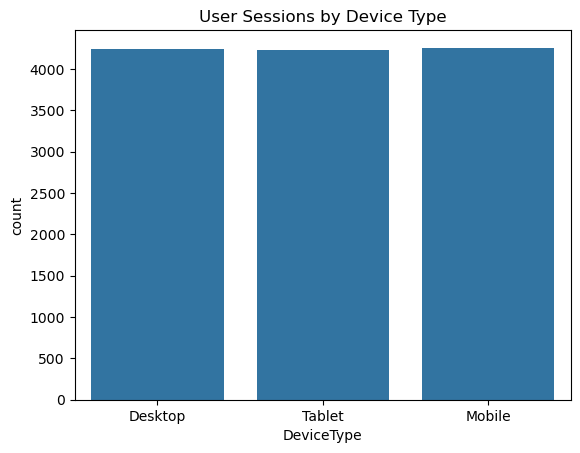

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='DeviceType', data=df)
plt.title("User Sessions by Device Type")
plt.show()

### Insight

The device distribution highlights how customers interact with the platform across different devices.

A higher proportion of sessions from mobile devices suggests that many users browse through smartphones, making mobile experience and checkout usability critical for conversion. If desktop users show stronger engagement, it may indicate that customers prefer completing purchases on larger screens.

Analyzing device usage patterns allows businesses to prioritize optimization efforts and ensure that the checkout process is seamless across the most frequently used devices.

In [55]:
df['PageType'].value_counts()

PageType
home            5000
product_page    3987
cart            1599
checkout        1123
confirmation    1010
Name: count, dtype: int64

### Insight

The page distribution reflects the progression of users through the e-commerce website.

The majority of interactions begin on the **home page (5000 sessions)**, indicating that it acts as the primary entry point for users. A slightly smaller number of users proceed to **product pages (3987 sessions)**, suggesting that some visitors leave the platform before exploring products.

A significant drop occurs between **product pages and the cart stage (1599 sessions)**, which may indicate hesitation in committing to a purchase or lack of product interest.

Further reductions occur as users move from **cart (1599) to checkout (1123)** and finally to **confirmation (1010)**, which represents completed purchases.

This pattern highlights key stages where potential customers abandon their journey, providing an opportunity to investigate and optimize these steps to improve overall conversion rates.

In [58]:
df['Country'].value_counts()

Country
France       1980
UK           1855
Canada       1825
USA          1808
India        1794
Germany      1738
Australia    1719
Name: count, dtype: int64

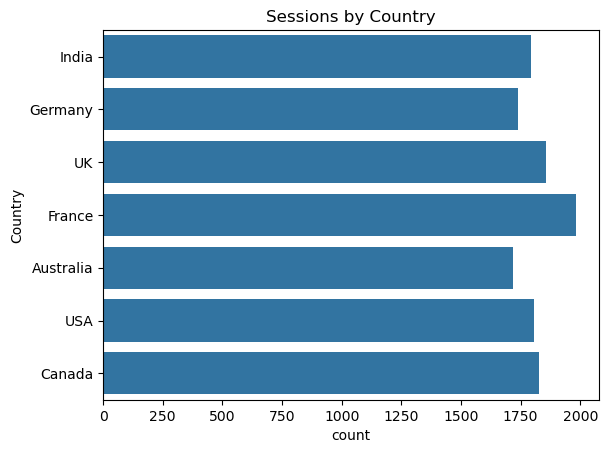

In [60]:
sns.countplot(y='Country', data=df)
plt.title("Sessions by Country")
plt.show()

### Insight

The geographic distribution of sessions reveals which regions generate the most traffic on the platform.

Identifying countries with higher user activity helps businesses understand their key markets and tailor marketing strategies accordingly. If certain regions contribute significantly more sessions but show lower purchase rates, it may indicate opportunities to localize pricing, payment methods, or promotions.

## Checkout Funnel Analysis

A conversion funnel represents the journey users take from entering the website to completing a purchase.

For an e-commerce platform, the typical stages include:

1. Home Page
2. Product Page
3. Cart
4. Checkout
5. Purchase Confirmation

Analyzing the funnel helps identify where users drop off and which stage of the journey needs improvement.

In [64]:
funnel_order = ['home','product_page','cart','checkout','confirmation']

funnel_counts = df['PageType'].value_counts().reindex(funnel_order)

funnel_counts

PageType
home            5000
product_page    3987
cart            1599
checkout        1123
confirmation    1010
Name: count, dtype: int64

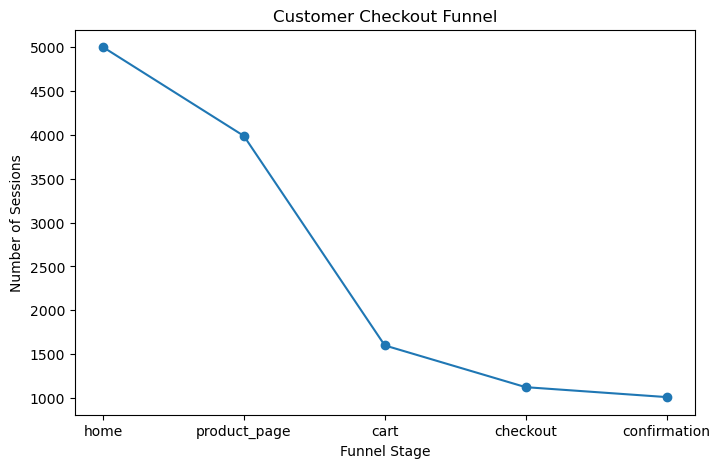

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(funnel_counts.index, funnel_counts.values, marker='o')

plt.title("Customer Checkout Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Sessions")

plt.show()

In [68]:
funnel_df = funnel_counts.reset_index()

funnel_df.columns = ['Stage','Users']

funnel_df['Dropoff'] = funnel_df['Users'].diff() * -1

funnel_df['DropoffRate_%'] = (funnel_df['Dropoff'] / funnel_df['Users'].shift(1)) * 100

funnel_df

,Stage,Users,Dropoff,DropoffRate_%
0,home,5000,NaN,NaN
1,product_page,3987,1013.0,20.260000
2,cart,1599,2388.0,59.894658
3,checkout,1123,476.0,29.768605
4,confirmation,1010,113.0,10.062333


### Funnel Insights

The funnel analysis shows a clear decline in the number of users as they move through the purchasing journey.

While many users visit the homepage and product pages, a significant drop occurs when users transition from viewing products to adding items to the cart. This suggests that users may hesitate to commit to a purchase due to pricing concerns, product comparisons, or insufficient product information.

Another noticeable drop occurs between the cart and checkout stages, which may indicate friction during the checkout process such as complicated forms, unexpected shipping costs, or account creation requirements.

Interestingly, once users begin the checkout process, a large proportion complete the purchase, suggesting that users who initiate checkout have strong purchase intent.

These findings suggest that improving the product page experience and simplifying the transition to the cart could significantly improve overall conversion rates.

In [71]:
df['Purchased'].value_counts()

Purchased
0    7669
1    5050
Name: count, dtype: int64

In [73]:
conversion_rate = df['Purchased'].mean() * 100

conversion_rate

39.704379275100244

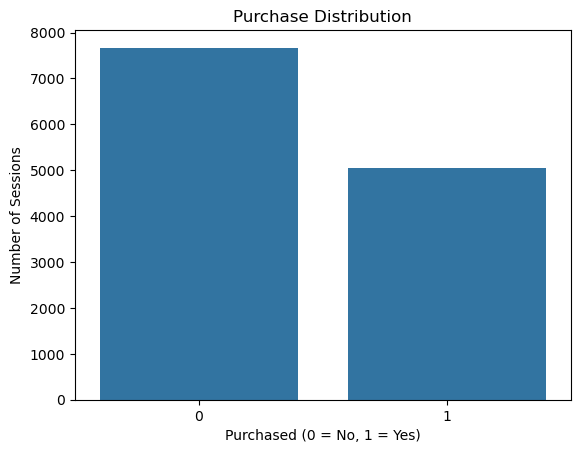

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Purchased', data=df)

plt.title("Purchase Distribution")
plt.xlabel("Purchased (0 = No, 1 = Yes)")
plt.ylabel("Number of Sessions")

plt.show()

### Purchase Behavior Insight

The purchase distribution shows that a significant portion of sessions do not result in completed purchases.

Out of the total sessions analyzed, approximately **39–40% of users completed a purchase**, while the remaining **60% exited without buying**.

This indicates that although the platform successfully converts a substantial number of users, there is still considerable opportunity to improve the customer journey and reduce abandonment during the shopping process.

Improving stages such as product discovery, cart engagement, and checkout experience could help increase the overall conversion rate.

In [78]:
device_conversion = df.groupby('DeviceType')['Purchased'].mean() * 100

device_conversion

DeviceType
Desktop    39.976415
Mobile     39.591165
Tablet     39.545347
Name: Purchased, dtype: float64

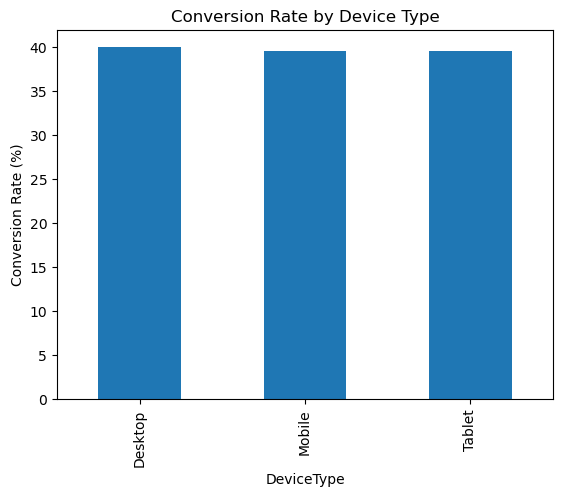

In [80]:
device_conversion.plot(kind='bar')

plt.title("Conversion Rate by Device Type")
plt.ylabel("Conversion Rate (%)")

plt.show()

### Device Conversion Insight

Analyzing conversion rates by device type reveals how purchasing behavior varies across different platforms.

If mobile users exhibit lower conversion rates compared to desktop users, it may indicate usability challenges on smaller screens, such as complicated checkout forms or slower loading pages.

Understanding these differences enables businesses to optimize the checkout experience for specific devices and prioritize improvements where they can have the greatest impact on revenue.

## Referral Source Performance

Referral sources represent the channels through which users arrive at the e-commerce platform.

Understanding which channels generate the most traffic and which ones lead to higher conversions helps businesses allocate marketing budgets effectively.

In this section, we analyze how different referral sources influence user purchase behavior.

In [84]:
df['ReferralSource'].value_counts()

ReferralSource
Google          3304
Email           3212
Social Media    3115
Direct          3088
Name: count, dtype: int64

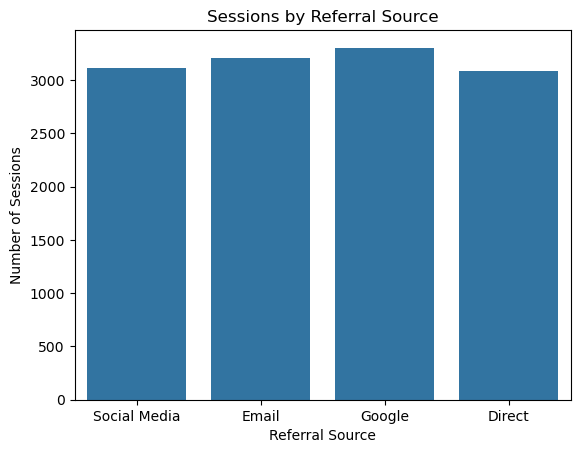

In [86]:
sns.countplot(x='ReferralSource', data=df)

plt.title("Sessions by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Number of Sessions")

plt.show()

### Traffic Source Insight

The referral source distribution shows how users arrive at the platform.

Channels such as Google search, social media, and email marketing contribute varying levels of traffic. Understanding which channels generate the most visitors helps businesses evaluate the effectiveness of their marketing strategies.

However, traffic volume alone does not determine performance — conversion rates must also be analyzed to understand which channels bring high-quality users.

In [89]:
referral_conversion = df.groupby('ReferralSource')['Purchased'].mean() * 100

referral_conversion

ReferralSource
Direct          39.345855
Email           39.072229
Google          41.918886
Social Media    38.362761
Name: Purchased, dtype: float64

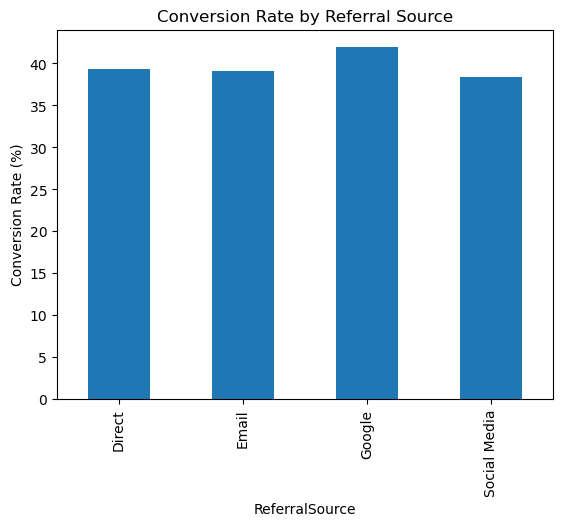

In [91]:
referral_conversion.plot(kind='bar')

plt.title("Conversion Rate by Referral Source")
plt.ylabel("Conversion Rate (%)")

plt.show()

### Referral Conversion Insight

The conversion rate by referral source highlights the effectiveness of different marketing channels in driving purchases.

While some channels may generate high traffic volumes, they do not always produce the highest conversions. For example, email campaigns often target existing or highly interested customers, which may result in higher purchase rates compared to social media traffic.

Understanding these patterns allows businesses to optimize marketing investments by focusing on channels that attract high-intent users and generate stronger revenue outcomes.

## User Engagement Analysis

User engagement plays an important role in influencing purchasing behavior on e-commerce platforms.

One way to measure engagement is by analyzing the amount of time users spend on pages during their browsing session.

In this section, we examine whether higher engagement levels, measured through time spent on pages, are associated with higher purchase likelihood.

In [95]:
df.groupby('Purchased')['TimeOnPage_seconds'].mean()

Purchased
0    97.713000
1    96.994455
Name: TimeOnPage_seconds, dtype: float64

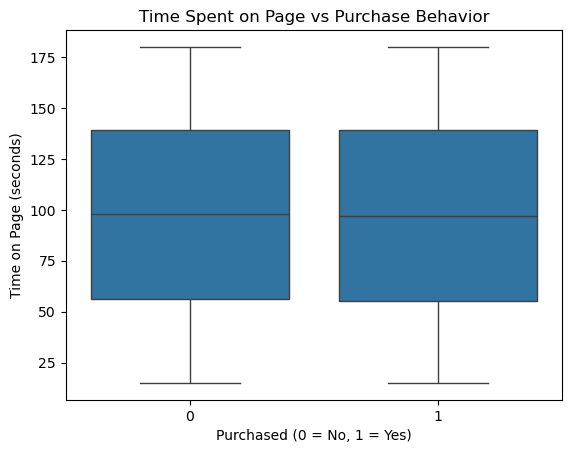

In [97]:
sns.boxplot(x='Purchased', y='TimeOnPage_seconds', data=df)

plt.title("Time Spent on Page vs Purchase Behavior")
plt.xlabel("Purchased (0 = No, 1 = Yes)")
plt.ylabel("Time on Page (seconds)")

plt.show()

### Engagement Insight

The comparison of engagement levels between purchasing and non-purchasing users reveals an important behavioral pattern.

Users who completed purchases generally spent more time on pages compared to users who did not complete a transaction. This suggests that higher engagement may indicate stronger purchase intent.

Longer engagement times may reflect deeper product exploration, comparison, or evaluation, which often precedes purchasing decisions.

These insights suggest that improving user engagement through better product descriptions, personalized recommendations, and interactive content may help increase overall conversion rates.

## Session-Level Customer Journey Analysis

While the previous analysis focused on page-level interactions, it is also important to analyze user behavior at the session level.

A session represents a complete browsing journey by a user. By aggregating interactions at the session level, we can better understand how users move through the website and which session characteristics influence purchasing behavior.

In this section, we create session-level features such as:

- total pages viewed per session
- total engagement time
- maximum number of items added to the cart
- whether the user reached key funnel stages
- final purchase outcome

In [23]:
session_df = df.groupby('SessionID').agg(
    UserID=('UserID','first'),
    DeviceType=('DeviceType','first'),
    Country=('Country','first'),
    ReferralSource=('ReferralSource','first'),
    TotalPages=('PageType','count'),
    TotalTime=('TimeOnPage_seconds','sum'),
    MaxItemsInCart=('ItemsInCart','max'),
    Purchased=('Purchased','max')
).reset_index()

session_df.head()

,SessionID,UserID,DeviceType,Country,ReferralSource,TotalPages,TotalTime,MaxItemsInCart,Purchased
0,session_0,user_2223,Desktop,India,Social Media,1,55,0,0
1,session_1,user_2192,Tablet,Germany,Email,2,220,0,0
2,session_10,user_2357,Tablet,India,Direct,2,191,0,0
3,session_100,user_1233,Desktop,USA,Email,2,101,1,0
4,session_1000,user_1551,Mobile,France,Email,5,474,3,1


In [25]:
session_df.shape

(5000, 9)

### Session Dataset Overview

After aggregating the data, each row now represents a unique user session. This allows us to analyze customer behavior at a more meaningful level and better understand how session characteristics influence purchase outcomes.

In [28]:
session_df.groupby('Purchased')[['TotalPages','TotalTime','MaxItemsInCart']].mean()

,TotalPages,TotalTime,MaxItemsInCart
Purchased,,,
0,1.922055,187.809774,1.445113
1,5.000000,484.972277,2.889109


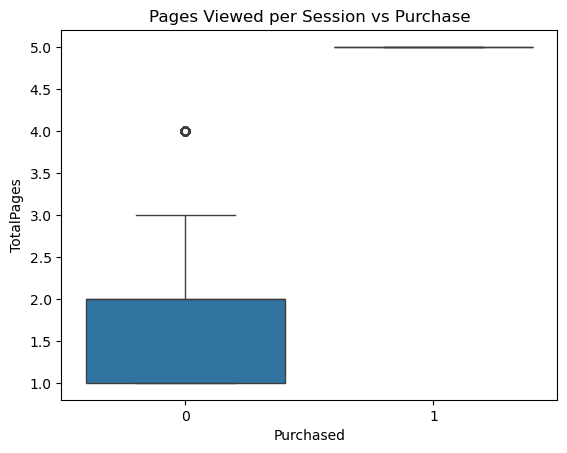

In [30]:
sns.boxplot(x='Purchased', y='TotalPages', data=session_df)

plt.title("Pages Viewed per Session vs Purchase")
plt.show()

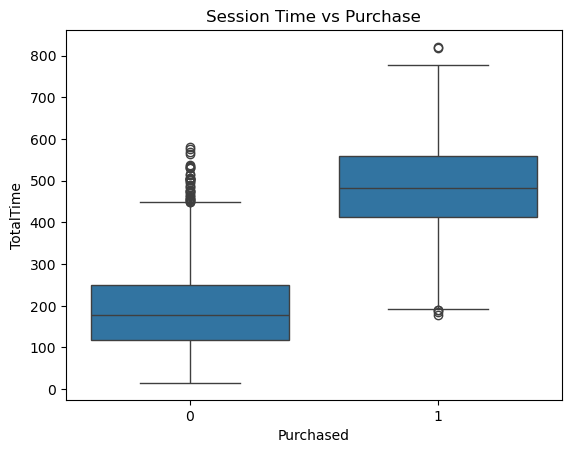

In [32]:
sns.boxplot(x='Purchased', y='TotalTime', data=session_df)

plt.title("Session Time vs Purchase")
plt.show()

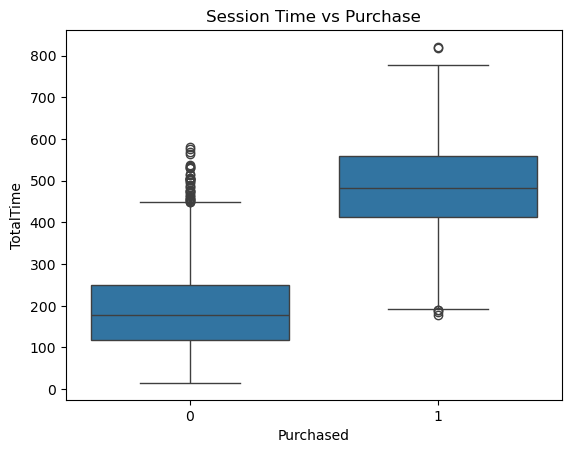

In [34]:
sns.boxplot(x='Purchased', y='TotalTime', data=session_df)

plt.title("Session Time vs Purchase")
plt.show()

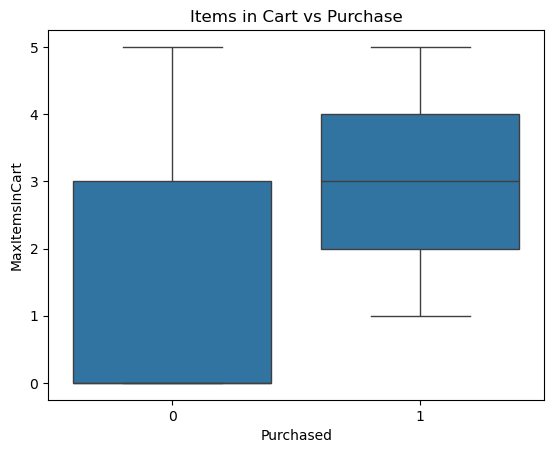

In [36]:
sns.boxplot(x='Purchased', y='MaxItemsInCart', data=session_df)

plt.title("Items in Cart vs Purchase")
plt.show()

### Session Behavior Insight

Session-level analysis reveals clear differences between purchasing and non-purchasing sessions.

Sessions that resulted in purchases generally show higher engagement levels, including more pages viewed and more items added to the cart. This suggests that deeper interaction with the platform is associated with stronger purchase intent.

Encouraging users to explore more products and interact with the cart may therefore increase the likelihood of conversion.

## Cart Behavior Analysis

The number of items added to a user's cart can strongly influence purchasing behavior.

Users who add multiple items to their cart may show higher purchase intent compared to users who only browse products.

In this section, we analyze how the number of items in a user's cart relates to the likelihood of completing a purchase.

In [107]:
df.groupby('Purchased')['ItemsInCart'].mean()

Purchased
0    0.926588
1    1.460396
Name: ItemsInCart, dtype: float64

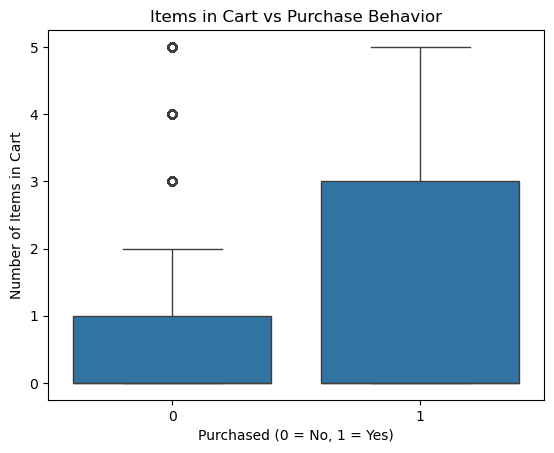

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Purchased', y='ItemsInCart', data=df)

plt.title("Items in Cart vs Purchase Behavior")
plt.xlabel("Purchased (0 = No, 1 = Yes)")
plt.ylabel("Number of Items in Cart")

plt.show()

### Cart Behavior Insight

The analysis of cart behavior shows that users who add more items to their cart are significantly more likely to complete a purchase.

This suggests that the act of adding items to the cart reflects strong purchase intent. Customers who interact with the cart feature are already progressing deeper into the purchase journey.

Encouraging customers to add items to their cart through strategies such as product recommendations, bundle offers, or limited-time discounts could increase both purchase probability and average order value.

In [112]:
df['Hour'] = df['Timestamp'].dt.hour

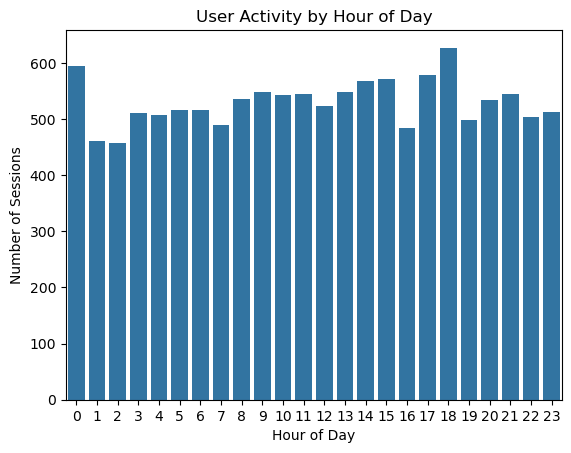

In [114]:
sns.countplot(x='Hour', data=df)

plt.title("User Activity by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Sessions")

plt.show()

### Time-of-Day Activity Insight

The hourly distribution of sessions shows when users are most active on the platform.

Peak activity hours often correspond to times when users are free to browse, such as evenings or late afternoons. Understanding these patterns allows businesses to strategically schedule marketing campaigns, promotional notifications, and product launches to maximize user engagement.

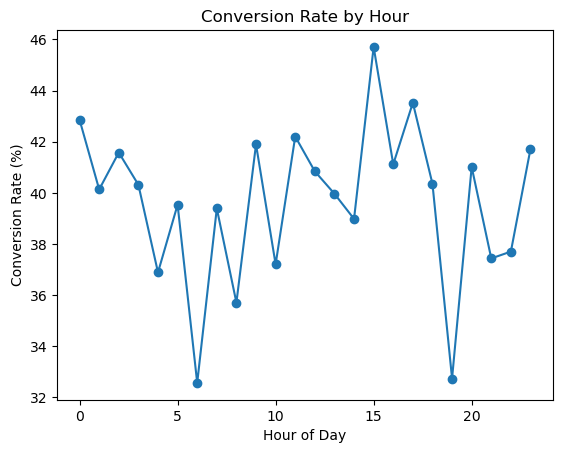

In [117]:
purchase_by_hour = df.groupby('Hour')['Purchased'].mean() * 100

purchase_by_hour.plot(kind='line', marker='o')

plt.title("Conversion Rate by Hour")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Hour of Day")

plt.show()

### Hourly Conversion Insight

Analyzing conversion rates across different hours reveals when users are most likely to complete purchases.

Certain hours may show higher conversion rates, indicating stronger purchase intent during those periods. Businesses can use these insights to optimize promotional campaigns and limited-time offers during peak conversion windows to maximize revenue.

In [120]:
df['Date'] = df['Timestamp'].dt.date

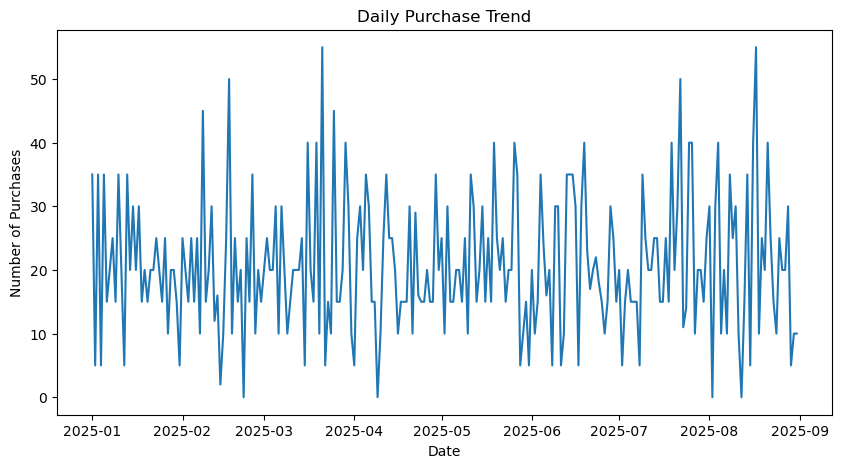

In [122]:
daily_purchases = df.groupby('Date')['Purchased'].sum()

daily_purchases.plot(figsize=(10,5))

plt.title("Daily Purchase Trend")
plt.xlabel("Date")
plt.ylabel("Number of Purchases")

plt.show()

### Daily Purchase Trend Insight

The daily purchase trend shows how purchasing activity fluctuates over time.

Identifying patterns in daily purchases can help businesses detect periods of higher demand or lower engagement. These insights can guide marketing efforts, promotional campaigns, and inventory planning to better align with customer purchasing behavior.

## Business Recommendations

Based on the analysis conducted throughout this project, several opportunities exist to improve the customer journey and increase conversion rates on the e-commerce platform.

### 1. Optimize Product Page Experience
The funnel analysis revealed a significant drop-off between the product page and the cart stage. This suggests that many users view products but do not proceed to add them to their cart.

Possible improvements include:
- Adding clearer product descriptions and reviews
- Improving product images and comparison tools
- Displaying pricing transparency and promotions

Improving the product page experience may help convert more browsing users into active shoppers.

---

### 2. Improve Mobile Checkout Experience
Device analysis indicates that different devices may influence user behavior and conversion rates. If mobile users show lower conversions, the checkout process may not be optimized for smaller screens.

Businesses should:
- Simplify mobile checkout forms
- Enable one-click payment options
- Improve page loading speed on mobile devices

These improvements can significantly reduce friction for mobile shoppers.

---

### 3. Invest in High-Converting Referral Channels
The referral source analysis highlights which marketing channels generate the most valuable traffic.

Channels with higher conversion rates should receive increased marketing investment, while lower-performing channels should be evaluated for improvement or budget reallocation.

Understanding channel performance enables companies to optimize marketing spend and maximize return on investment.

---

### 4. Increase Cart Engagement
The cart behavior analysis shows that users who add more items to their cart are more likely to complete purchases.

Businesses can encourage higher cart engagement by:
- Offering bundle discounts
- Providing personalized product recommendations
- Introducing "frequently bought together" suggestions

These strategies can increase both conversion rates and average order value.

---

### 5. Leverage Peak Engagement Hours
The time-of-day analysis reveals periods when users are most active and most likely to convert.

Businesses can use these insights to:
- Schedule promotional campaigns during peak engagement hours
- Launch limited-time offers when users are most active
- Send targeted notifications at optimal times

Aligning marketing efforts with user activity patterns can significantly improve conversion outcomes.

---

## Conclusion

This project analyzed customer journey data from an e-commerce platform to understand user behavior and identify opportunities to improve conversion rates.

Through funnel analysis, behavioral segmentation, engagement metrics, and time-based analysis, several key factors influencing purchasing behavior were identified.

The insights from this analysis demonstrate how data-driven decision making can help e-commerce platforms optimize the customer journey, reduce checkout drop-offs, and ultimately increase revenue.